[P0839-MAC.local:46058] shmem: mmap: an error occurred while determining whether or not /var/folders/ll/9jjvr_992z74qxllmgyqhl6w0000gp/T//ompi.P0839-MAC.502/jf.0/2096627712/sm_segment.P0839-MAC.502.7cf80000.0 could be created.


Defining variational problem heat transfers
Solving stationary heat equation
Defining initial values
Defining variational problem
Defining source terms
Defining boundary conditions
Time stepping...


/Users/fj1628/anaconda3/envs/festim-env/lib/python3.11/site-packages/festim/generic_simulation.py:398: UserWarning: To ensure that TXTExport exports data at the desired times TXTExport.times are added to milestones
  warnings.warn(msg)


/Users/fj1628/anaconda3/envs/festim-env/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(
/Users/fj1628/anaconda3/envs/festim-env/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(
/Users/fj1628/anaconda3/envs/festim-env/lib/python3.11/site-packages/festim/exports/derived_quantities/derived_quantities.py:129: DeprecationWarning: The current derived_quantities title style will be deprecated in a future release, please use show_units=True instead
  warnings.warn(


100.0 %        3.2e+07 s    Elapsed time so far: 187.1 s


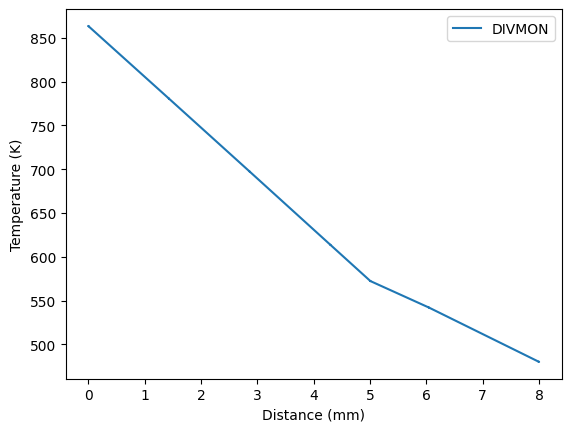

In [1]:
# DIVMON


import festim as F


my_model = F.Simulation()

import numpy as np

my_model.mesh = F.MeshFromVertices(np.linspace(0, 8e-3, num=15000))

tungsten = F.Material(
    id=1,
    D_0=1.5e-07,  # m2/s
    E_D=0.265,  # eV
    S_0=2.7e24,
    E_S=1.14,
    borders=[0,5e-3],
    thermal_cond=173,  # W/mK
)

copper = F.Material(
    id=2,
    D_0=6.6e-7,
    E_D=0.387,
    S_0=3.14e24,
    E_S=0.572,
    borders=[5e-3, 6e-3],
    thermal_cond=350,
)

cucrzr = F.Material(
	id=3, 
	D_0=4.8e-7, 
	E_D=0.42, 
	S_0=4.27e23, 
	E_S=0.39,
	borders=[6e-3, 8e-3],
	thermal_cond=320
)

my_model.materials = [tungsten, copper, cucrzr]

w_density = 6.3e28  # atom/m3  
copper_density = 9.2e28
cucrzr_density = 9.2e28  

damage_percent = 0.01 # 0.1-2 dpa/fpy W neutronic damage

trap_W_1 = F.Trap( 
	k_0 = [1.5e-7/((1.1e-10)**2 * 6 * w_density),6.6e-7 / ((3.6e-10)**2 * 1 * copper_density),4.8e-7 / ((3.6e-10)**2 * 1 * cucrzr_density)],
	E_k= [0.265,0.387,0.418],
	p_0=[1.2397e13,5.0926e12,7.3472e12],
	E_p=[0.83,0.5,0.53], 
	density = [w_density*0.00118,copper_density*0.00005,3.7e24],
	materials = [tungsten,copper,cucrzr]
)
            
trap_W_2 = F.Trap(
	k_0 = 1.5e-7/((1.1e-10)**2 * 6 * w_density),
	E_k= 0.265, 
	p_0=1.2397e13,
	E_p=0.97,
	density = w_density*0.000722,
	materials = [tungsten]
)

trap_W_3 = F.Trap(
	k_0=1.5e-7/(1.1e-10**2 * 6 * w_density),
	E_k=0.265,
	p_0=1e13,
	E_p=1.51, # change to 2.05 when necessary
	density = damage_percent*w_density,
	materials = tungsten
) 
my_model.traps = [trap_W_1, trap_W_2, trap_W_3]

my_model.T = F.HeatTransferProblem(transient=False)

my_model.boundary_conditions = [
    F.ImplantationDirichlet(surfaces=1, phi=0.23e24, R_p=1.1e-9, D_0=1.5e-07, E_D=0.265), # mean depth may be too low, maybe order of magnitude higher
    F.DirichletBC(surfaces=2, value=0, field=0),
    F.FluxBC(surfaces=1, value=10e6, field="T"),
   # F.DirichletBC(surfaces=1, value=1273, field="T"),
    F.DirichletBC(surfaces=2, value=480, field="T"), # Set coolant temp to 573K as 473K messes it up for some reason
]

my_model.sources = [ 
		F.Source(value=28.8e6, volume=1, field='T'), # Neutronic heating W: 1.3-28.8 MW/m3
		F.Source(value=8.1e6, volume=[2, 3], field='T'), # Neutronic heating Cu & CuCrZr: 0.3-8.1 MW/m3
]
		
# Stepsize
my_model.dt = F.Stepsize(
    initial_value=0.5,
    stepsize_change_ratio=1.1
)


# Settings
my_model.settings = F.Settings(
    absolute_tolerance=1e14, relative_tolerance=1e-04, final_time=3.2e7, 
    chemical_pot=True, traps_element_type="DG"
)

retention_1_DIVMON = F.TotalVolume("retention", volume = 1)
retention_2 = F.TotalVolume("retention", volume = 2)
retention_3 = F.TotalVolume("retention", volume = 3)


derived_quantities = F.DerivedQuantities(
    [retention_1_DIVMON, retention_2, retention_3]
)

results_folder = "PFC_retention_profiles/DIVMON"

txt_export = F.TXTExport(
    field='T',
    filename=results_folder + '/T.txt',
    times=[3.2e7],
    )

my_model.exports = [F.DerivedQuantities([retention_1_DIVMON, retention_2, retention_3], filename = results_folder + "/derived_qs.csv"), txt_export]

my_model.initialise()
my_model.run()

import matplotlib.pyplot as plt

temp_data = np.loadtxt(results_folder + '/T.txt', delimiter=',', dtype = 'float', skiprows = 1 )
dist = temp_data[:, 0] * 1000
temp = temp_data[:, 1]

plt.plot(dist, temp, label='DIVMON')
plt.ylabel('Temperature (K)')
plt.xlabel('Distance (mm)')
plt.legend()




